# Fitting the unified sleep model to irregular observations

This tutorial demonstrates how to recover the parameters of a sleep-homeostasis model from a **scalar signal** (e.g. a PVT-like performance measure) sampled at irregular times.

We use the `"Chronic Sleep Restriction: 21h / 3h → Recovery: 16h / 8h"` diary as the ground-truth schedule — 5 days of CSR followed by 3 recovery days, 192 h in total.

The forward pass (`Model.compute`) is implemented with PyTorch, so gradients flow from the observation loss back to the physiological time constants (`t_w`, `t_s`, `t_la`), which we fit with Adam.


In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.insert(0,"C:/Users/robin/Documents/Postdoc_Stanford/UMP_computation/sleep/src/")  # ou le chemin absolu vers ton dossier

from sleep import Model

%load_ext autoreload
%autoreload 2

In [8]:
diary = pd.read_csv("data/diary.csv")
diary.head()

,key,asleep,awake,rested
0,Adaptation → Sleep Deprivation: 64h → Recovery...,NaN,0.0,False
1,Adaptation → Sleep Deprivation: 64h → Recovery...,16.0,24.0,False
2,Adaptation → Sleep Deprivation: 64h → Recovery...,40.0,48.0,True
3,Adaptation → Sleep Deprivation: 64h → Recovery...,112.0,120.0,False
4,Adaptation → Sleep Deprivation: 64h → Recovery...,136.0,144.0,False


## Forward evaluation

Instantiate the model and visualise homeostasis and debt trajectories for all three diaries at the default parameters.


In [9]:
model = Model("unified", diary)
print(model)

Total of 3 diaries provided.
----------------------------------------
Unified sleep model computing:
- Homeostasis (s): sleep pressure
- Debt (d): sleep debt

During wake:
  ds/dt = (1 - s) / t_w
  dd/dt = (-d + 1) / t_la

During sleep:
  ds/dt = -(s - d) / t_s
  dd/dt = (-d - wsr) / t_la


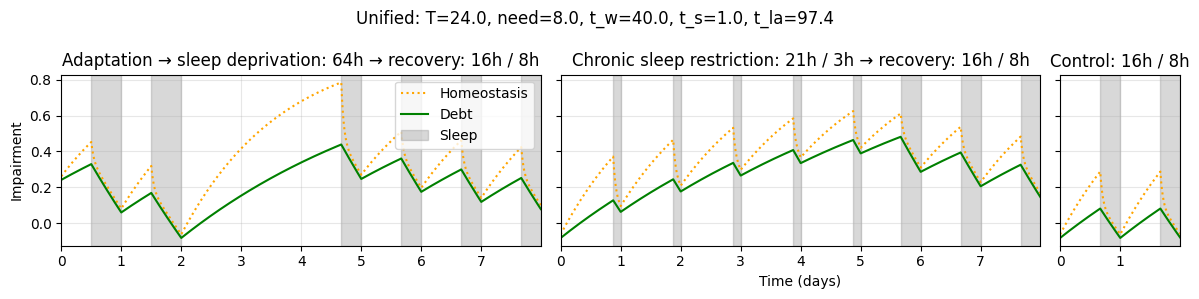

In [4]:
fig, axs = model.plot(key=list(model.key_id.keys()))
fig.savefig("../figures/example.png", dpi=300, bbox_inches="tight")

## Fitting to irregular scalar observations

We now treat this as an inverse problem. Given noisy measurements `y_i = s(t_i) + ε_i` of the homeostasis signal at irregular times, can we recover the time constants `t_w, t_s, t_la`?

- **Schedule:** Chronic Sleep Restriction → Recovery (192 h).
- **Sampling:** 4–6 observations per day, drawn uniformly within each 24 h window.
- **Ground truth:** package defaults (`t_w=40`, `t_s=1`, `t_la=97.4`), with `T=24`, `need=8` held fixed.
- **Noise:** Gaussian, σ = 0.03.
- **Optimizer:** Adam on _log-parameterized_ time constants. This guarantees positivity under unconstrained gradient descent; the ordering constraints `t_s, t_w < t_la` are satisfied at the optimum and checked post-hoc.


In [10]:
key = "Chronic Sleep Restriction: 21h / 3h → Recovery: 16h / 8h"
diary_key = diary.loc[diary.key == key]
t_start = float(diary_key.awake.min())
t_end = float(diary_key.awake.max())
n_days = int((t_end - t_start) / 24)

# Draw 4–6 irregular observation times per 24 h window.
rng = np.random.default_rng(42)
obs_times = np.concatenate(
    [
        np.sort(rng.uniform(t_start + d * 24, t_start + (d + 1) * 24, rng.integers(4, 7)))
        for d in range(n_days)
    ]
)

# Ground-truth signal = homeostasis at default params (as numpy).
y_true = model.compute(key=key, time=obs_times)["homeostasis"]

# Observation = signal + Gaussian noise.
noise_std = 0.03
y_obs = y_true + rng.normal(0.0, noise_std, size=obs_times.shape)

print(
    f"{len(obs_times)} observations across {n_days} days (avg {len(obs_times) / n_days:.1f} / day)"
)

41 observations across 8 days (avg 5.1 / day)


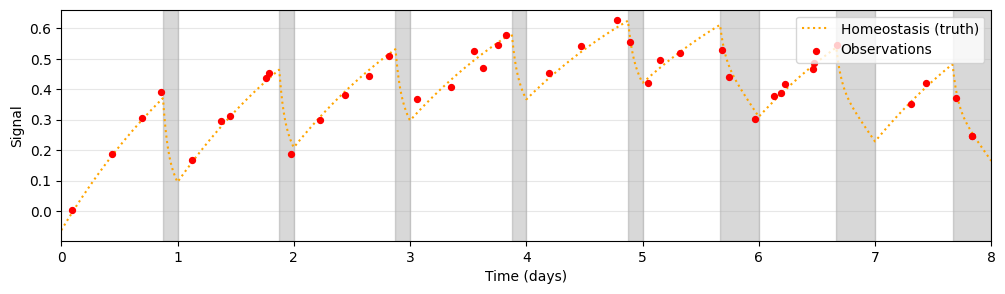

In [11]:
# Sanity check: overlay observations on the continuous ground-truth trajectory.
t_dense = np.linspace(t_start, t_end, 2000)
s_dense_truth = model.compute(key=key, time=t_dense)["homeostasis"]

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(
    (t_dense - t_start) / 24,
    s_dense_truth,
    color="orange",
    linestyle="dotted",
    lw=1.5,
    label="Homeostasis (truth)",
)
for asleep, awake in zip(diary_key["asleep"], diary_key["awake"]):
    if pd.notna(asleep):
        ax.axvspan((asleep - t_start) / 24, (awake - t_start) / 24, color="gray", alpha=0.3)
ax.scatter((obs_times - t_start) / 24, y_obs, color="red", s=18, zorder=3, label="Observations")
ax.set_xlim(0, (t_end - t_start) / 24)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Signal")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.show()

In [12]:
# Log-parameterization keeps time constants positive under unconstrained optimisation.
# Initial values are deliberately perturbed away from the truth.
log_t_w = torch.tensor(float(np.log(30.0)), requires_grad=True)
log_t_s = torch.tensor(float(np.log(0.5)), requires_grad=True)
log_t_la = torch.tensor(float(np.log(70.0)), requires_grad=True)

obs_t = torch.as_tensor(obs_times, dtype=torch.float32)
y_obs_t = torch.as_tensor(y_obs, dtype=torch.float32)

truth = {"t_w": 40.0, "t_s": 1.0, "t_la": 97.4}
init = {
    "t_w": float(torch.exp(log_t_w)),
    "t_s": float(torch.exp(log_t_s)),
    "t_la": float(torch.exp(log_t_la)),
}
print("Ground truth:", truth)
print("Initial     :", {k: round(v, 3) for k, v in init.items()})

Ground truth: {'t_w': 40.0, 't_s': 1.0, 't_la': 97.4}
Initial     : {'t_w': 30.0, 't_s': 0.5, 't_la': 70.0}


C:\Users\robin\AppData\Local\Temp\ipykernel_26340\2627190816.py:12: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  "t_w": float(torch.exp(log_t_w)),


In [13]:
optim = torch.optim.Adam([log_t_w, log_t_s, log_t_la], lr=0.05)

n_steps = 300
losses = []
for step in range(n_steps):
    optim.zero_grad()
    params = {"t_w": torch.exp(log_t_w), "t_s": torch.exp(log_t_s), "t_la": torch.exp(log_t_la)}
    pred = model.compute(key=key, time=obs_t, **params)
    loss = ((pred["homeostasis"] - y_obs_t) ** 2).mean()
    loss.backward()
    optim.step()
    losses.append(loss.item())

fitted = {
    "t_w": float(torch.exp(log_t_w)),
    "t_s": float(torch.exp(log_t_s)),
    "t_la": float(torch.exp(log_t_la)),
}

print(f"Final loss: {losses[-1]:.5f}\n")
print(f"{'Parameter':<6} {'Truth':>10} {'Initial':>10} {'Fitted':>10} {'Rel. err':>10}")
for k in ("t_w", "t_s", "t_la"):
    rel = abs(fitted[k] - truth[k]) / truth[k]
    print(f"{k:<6} {truth[k]:>10.3f} {init[k]:>10.3f} {fitted[k]:>10.3f} {rel:>9.1%}")

Final loss: 0.00039

Parameter      Truth    Initial     Fitted   Rel. err
t_w        40.000     30.000     37.701      5.7%
t_s         1.000      0.500      0.673     32.7%
t_la       97.400     70.000     95.884      1.6%


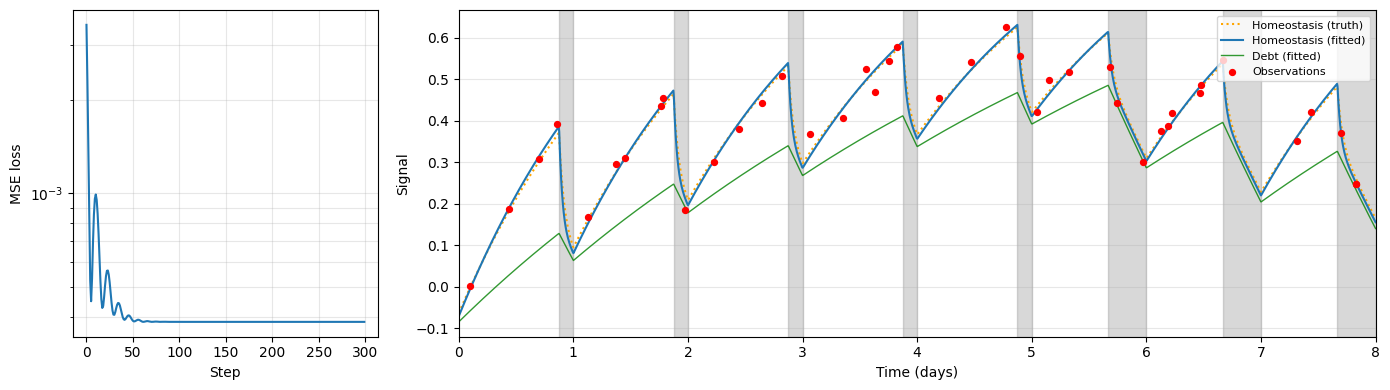

In [14]:
# Diagnostics: loss curve + fitted vs ground-truth trajectories with observations.
out_fit = model.compute(key=key, time=t_dense, **fitted)
t_days = (t_dense - t_start) / 24

fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1, 3]})

axes[0].semilogy(losses)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("MSE loss")
axes[0].grid(alpha=0.3, which="both")

ax = axes[1]
ax.plot(
    t_days, s_dense_truth, color="orange", linestyle="dotted", lw=1.5, label="Homeostasis (truth)"
)
ax.plot(t_days, out_fit["homeostasis"], color="C0", lw=1.5, label="Homeostasis (fitted)")
ax.plot(t_days, out_fit["debt"], color="green", lw=1.0, alpha=0.8, label="Debt (fitted)")
for asleep, awake in zip(diary_key["asleep"], diary_key["awake"]):
    if pd.notna(asleep):
        ax.axvspan((asleep - t_start) / 24, (awake - t_start) / 24, color="gray", alpha=0.3)
ax.scatter((obs_times - t_start) / 24, y_obs, color="red", s=18, zorder=3, label="Observations")
ax.set_xlim(0, (t_end - t_start) / 24)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Signal")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()